In [27]:
!pip install sentence-transformers numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [28]:
import json

try:
    with open("code_corpus.json", "r", encoding="utf-8") as f:
        code_corpus = json.load(f)

    with open("eval_questions.json", "r", encoding="utf-8") as f:
        eval_questions = json.load(f)

    print("проверка успешна!")
    print(f"Успешно загружено фрагментов кода: {len(code_corpus)} элементов.")
    print(f"Успешно загружено тестовых вопросов: {len(eval_questions)} элементов.")
except FileNotFoundError as e:
    print(f"Файл не найден")

проверка успешна!
Успешно загружено фрагментов кода: 200 элементов.
Успешно загружено тестовых вопросов: 25 элементов.


In [29]:
from sentence_transformers import SentenceTransformer

models = {
    "MiniLM-L12 (Быстрая)": SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"),
    "MPNET-Base (Точная)": SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"),
    "E5-Base (Контрастивная)": SentenceTransformer("intfloat/multilingual-e5-base")
}

print("\nвсе модели загружены успешно")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7483.72it/s]



все модели загружены успешно


In [30]:
import numpy as np

import pandas as pd
from sentence_transformers import util

results_table = {}
all_model_embeddings = {}

def prepare_text(chunk, model_name):
    text = f"Функция {chunk['function_name']}: {chunk['description']}"
    return f"passage: {text}" if "E5" in model_name else text

def prepare_query(query_text, model_name):
    return f"query: {query_text}" if "E5" in model_name else query_text

# Запуск вычислений
for model_name, model in models.items():
    print(f"Вычисляем для: {model_name}...")

    corpus_texts = [prepare_text(chunk, model_name) for chunk in code_corpus]
    corpus_embeddings = model.encode(corpus_texts, convert_to_tensor=True)
    all_model_embeddings[model_name] = corpus_embeddings.cpu().numpy()

    correct_top3_count = 0

    for q in eval_questions:
        # Используем точный ключ 'query' из твоего файла
        query_text = prepare_query(q["query"], model_name)
        query_embedding = model.encode(query_text, convert_to_tensor=True)

        cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
        top_results = np.argsort(cos_scores.cpu().numpy())[::-1][:3]

        # Сверяем строковые ID
        top_chunks_ids = [str(code_corpus[idx]["id"]) for idx in top_results]
        correct_id = str(q["correct_chunk_id"])

        if correct_id in top_chunks_ids:
            correct_top3_count += 1

    results_table[model_name] = correct_top3_count / len(eval_questions)

df_results = pd.DataFrame(list(results_table.items()), columns=["Модель", "Precision@3"])
df_results

Вычисляем для: MiniLM-L12 (Быстрая)...
Вычисляем для: MPNET-Base (Точная)...
Вычисляем для: E5-Base (Контрастивная)...


,Модель,Precision@3
0,MiniLM-L12 (Быстрая),0.80
1,MPNET-Base (Точная),0.92
2,E5-Base (Контрастивная),1.00


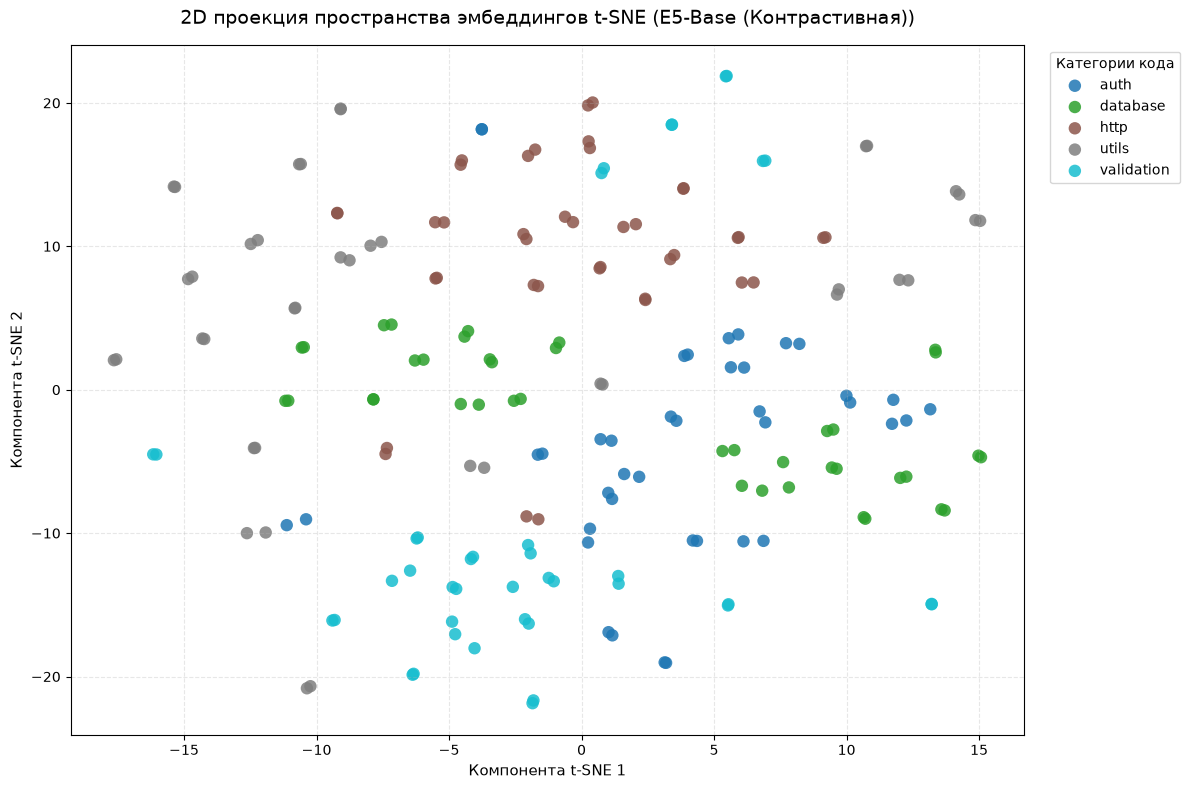

In [31]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# беру эмбеддинги лучшей модели (E5-Base)
best_model_key = "E5-Base (Контрастивная)"
best_embeddings = all_model_embeddings[best_model_key]

# извлекаю категории для каждой точки в корпусе
categories = [chunk["category"] for chunk in code_corpus]
unique_categories = sorted(list(set(categories)))

# настройка алгоритма t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(code_corpus)//4))
coords = tsne.fit_transform(best_embeddings)

# график
plt.figure(figsize=(12, 8), dpi=100)

import matplotlib as mpl
colors = mpl.colormaps["tab10"](np.linspace(0, 1, len(unique_categories)))

for i, cat in enumerate(unique_categories):
    idx = [j for j, c in enumerate(categories) if c == cat]
    plt.scatter(coords[idx, 0], coords[idx, 1],
                color=colors[i],
                label=cat,
                alpha=0.85,
                edgecolors='none',
                s=80)

plt.title(f"2D проекция пространства эмбеддингов t-SNE ({best_model_key})", fontsize=14, pad=15)
plt.xlabel("Компонента t-SNE 1", fontsize=11)
plt.ylabel("Компонента t-SNE 2", fontsize=11)

# выношу легенду вбок
plt.legend(title="Категории кода", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# сохраняю график в файл для архива практики
plt.savefig("../Search_Navigator_Nesterova_Violetta/tsne_clusters.png", bbox_inches='tight')
plt.show()

In [34]:
# --- ТЕСТОВАЯ ДИАГНОСТИКА ДАННЫХ ---
print(f"Статус eval_questions: тип {type(eval_questions)}, длина {len(eval_questions)}")
print(f"Статус code_corpus: тип {type(code_corpus)}, длина {len(code_corpus)}")
print(f"Доступные ключи в all_model_embeddings: {list(all_model_embeddings.keys())}")
if len(eval_questions) > 0:
    print(f"Ключи первого вопроса: {list(eval_questions[0].keys())}")

Статус eval_questions: тип <class 'list'>, длина 25
Статус code_corpus: тип <class 'list'>, длина 200
Доступные ключи в all_model_embeddings: ['MiniLM-L12 (Быстрая)', 'MPNET-Base (Точная)', 'E5-Base (Контрастивная)']
Ключи первого вопроса: ['question_id', 'query', 'language', 'correct_chunk_id']


In [35]:
import re
import torch
import pandas as pd
import numpy as np
from sentence_transformers import util

# 1. Проверяем ключ вопроса
first_q = eval_questions[0]
query_key = "query" if "query" in first_q else ("question" if "question" in first_q else list(first_q.keys())[0])
print(f"Используем ключ вопроса: '{query_key}'")

id_to_category = {str(item["id"]): item["category"] for item in code_corpus}
error_records = []
lang_results = []

# 2. Запуск сквозного анализа
for model_name, model in models.items():
    # Защита от несовпадения имен ключей эмбеддингов
    emb_key = model_name
    if emb_key not in all_model_embeddings:
        # Пробуем найти похожий ключ, если имена чуть отличаются
        emb_key = [k for k in all_model_embeddings.keys() if model_name.split()[0] in k][0]

    corpus_embs_tensor = torch.tensor(all_model_embeddings[emb_key]).to(model.device)
    print(f"\n[Обработка] Модель: {model_name}...")

    # Разделение по языкам для текущей модели
    for lang in ["ru", "en"]:
        if lang == "ru":
            lang_questions = [
                q for q in eval_questions
                if len(re.findall(r'[а-яА-Я]', str(q[query_key]))) > len(re.findall(r'[a-zA-Z]', str(q[query_key])))
            ]
        else:
            lang_questions = [
                q for q in eval_questions
                if len(re.findall(r'[а-яА-Я]', str(q[query_key]))) <= len(re.findall(r'[a-zA-Z]', str(q[query_key])))
            ]

        if len(lang_questions) == 0:
            print(f"  -> Для языка {lang.upper()} нет вопросов.")
            continue

        correct = 0
        for q in lang_questions:
            query_text = prepare_query(q[query_key], model_name)
            query_embedding = model.encode(query_text, convert_to_tensor=True)

            cos_scores = util.cos_sim(query_embedding, corpus_embs_tensor)[0]
            top_results = np.argsort(cos_scores.cpu().numpy())[::-1][:3]

            top_chunks_ids = [str(code_corpus[idx]["id"]) for idx in top_results]
            correct_id = str(q["correct_chunk_id"])

            # Фиксируем попадание для языковой метрики
            if correct_id in top_chunks_ids:
                correct += 1
            else:
                # Фиксируем ошибку для таблицы категорий (только один раз, чтобы не дублировать в циклах языков)
                if lang == "ru": # Чтобы не считать одну ошибку дважды в цикле ru/en
                    category = id_to_category.get(correct_id, "unknown")
                    error_records.append({
                        "Модель": model_name,
                        "Категория": category,
                        "Количество ошибок": 1
                    })

        precision_lang = correct / len(lang_questions)
        lang_results.append({
            "Модель": model_name,
            "Язык запроса": lang.upper(),
            "Precision@3": round(precision_lang, 3)
        })

# --- ПРИНУДИТЕЛЬНЫЙ ВЫВОД РЕЗУЛЬТАТОВ ---
print("\n" + "="*50)
print("ПОЛУЧЕННЫЕ ТАБЛИЦЫ РЕЗУЛЬТАТОВ:")
print("="*50)

print("\n1. ТАБЛИЦА МУЛЬТИЯЗЫЧНОСТИ:")
if lang_results:
    print(pd.DataFrame(lang_results).to_string(index=False))
else:
    print("Данные по языкам не собрались.")

print("\n2. ТАБЛИЦА ОШИБОК ПО КАТЕГОРИЯМ:")
if error_records:
    df_errs = pd.DataFrame(error_records)
    df_grouped = df_errs.groupby(["Модель", "Категория"]).sum().reset_index()
    print(df_grouped.to_string(index=False))
else:
    print("Ошибок не обнаружено! Все модели отработали на 100% точно (Precision@3 = 1.0).")

Используем ключ вопроса: 'query'

[Обработка] Модель: MiniLM-L12 (Быстрая)...

[Обработка] Модель: MPNET-Base (Точная)...

[Обработка] Модель: E5-Base (Контрастивная)...

ПОЛУЧЕННЫЕ ТАБЛИЦЫ РЕЗУЛЬТАТОВ:

1. ТАБЛИЦА МУЛЬТИЯЗЫЧНОСТИ:
                 Модель Язык запроса  Precision@3
   MiniLM-L12 (Быстрая)           RU        0.733
   MiniLM-L12 (Быстрая)           EN        0.900
    MPNET-Base (Точная)           RU        0.933
    MPNET-Base (Точная)           EN        0.900
E5-Base (Контрастивная)           RU        1.000
E5-Base (Контрастивная)           EN        1.000

2. ТАБЛИЦА ОШИБОК ПО КАТЕГОРИЯМ:
              Модель  Категория  Количество ошибок
 MPNET-Base (Точная)       auth                  1
MiniLM-L12 (Быстрая)       auth                  1
MiniLM-L12 (Быстрая)   database                  1
MiniLM-L12 (Быстрая)       http                  1
MiniLM-L12 (Быстрая) validation                  1
